# QROM Scaling for Tridiagonal Matrices

This notebook compares Qualtran QROM gate counts for increasing system size `N`
for two matrix families with stencil entries `[-1, 2, -1]`:
- Banded Toeplitz (open boundary)
- Circulant (periodic boundary)

For each row, we store up to 3 `(column, value)` pairs and count QROM resources.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from qualtran.bloqs.data_loading.qrom import QROM
from qualtran.resource_counting import QECGatesCost, get_cost_value


In [6]:
def toeplitz_tridiagonal_data(n: int):
    """Open-boundary tridiagonal with stencil [-1, 2, -1]."""
    cols = np.zeros((n, 3), dtype=int)
    vals = np.zeros((n, 3), dtype=int)

    for i in range(n):
        # Left, center, right slots.
        # Missing neighbors stay as zero-value placeholders.
        cols[i, 1] = i
        vals[i, 1] = 2
        if i > 0:
            cols[i, 0] = i - 1
            vals[i, 0] = -1
        else:
            cols[i, 0] = i
        if i < n - 1:
            cols[i, 2] = i + 1
            vals[i, 2] = -1
        else:
            cols[i, 2] = i

    return cols, vals


def circulant_tridiagonal_data(n: int):
    """Periodic tridiagonal with stencil [-1, 2, -1]."""
    cols = np.zeros((n, 3), dtype=int)
    vals = np.zeros((n, 3), dtype=int)

    for i in range(n):
        cols[i, 0] = (i - 1) % n
        cols[i, 1] = i
        cols[i, 2] = (i + 1) % n
        vals[i, :] = np.array([-1, 2, -1], dtype=int)

    return cols, vals


def encode_signed_values(vals: np.ndarray, offset: int = 1) -> np.ndarray:
    """Map signed entries to non-negative ints for QROM storage."""
    enc = vals + offset
    if np.any(enc < 0):
        raise ValueError('Encoding produced negative values; increase offset.')
    return enc.astype(int)


In [7]:
def qrom_cost_for_matrix_pattern(builder, n: int):
    cols, vals = builder(n)
    vals_enc = encode_signed_values(vals, offset=1)

    # Load two datasets indexed by (row, local_slot):
    #   dataset 0 -> column index
    #   dataset 1 -> encoded matrix value
    qrom = QROM.build_from_data(cols, vals_enc)
    gc = get_cost_value(qrom, QECGatesCost())

    return {
        'n': int(n),
        't': int(gc.t),
        'toffoli': int(gc.toffoli),
        'and_bloq': int(gc.and_bloq),
        'clifford': int(gc.clifford),
        'rotation': int(gc.rotation),
        'measurement': int(gc.measurement),
        'total_t_equiv': int(gc.total_t_count()),
    }


sizes = [2**k for k in range(2, 11)]  # 4 .. 1024
toeplitz_rows = [qrom_cost_for_matrix_pattern(toeplitz_tridiagonal_data, n) for n in sizes]
circulant_rows = [qrom_cost_for_matrix_pattern(circulant_tridiagonal_data, n) for n in sizes]


In [8]:
def print_table(title, rows):
    print(title)
    print(f"{'n':>8} {'t':>6} {'toff':>6} {'and':>6} {'cliff':>8} {'T_eq':>8}")
    for r in rows:
        print(f"{r['n']:8d} {r['t']:6d} {r['toffoli']:6d} {r['and_bloq']:6d} {r['clifford']:8d} {r['total_t_equiv']:8d}")
    print()

print_table('Toeplitz tridiagonal [-1,2,-1]', toeplitz_rows)
print_table('Circulant tridiagonal [-1,2,-1]', circulant_rows)


Toeplitz tridiagonal [-1,2,-1]
       n      t   toff    and    cliff     T_eq
       4      0      0     10       44       40
       8      0      0     22      100       88
      16      0      0     46      224      184
      32      0      0     94      496      376
      64      0      0    190     1088      760
     128      0      0    382     2368     1528
     256      0      0    766     5120     3064
     512      0      0   1534    11008     6136
    1024      0      0   3070    23552    12280

Circulant tridiagonal [-1,2,-1]
       n      t   toff    and    cliff     T_eq
       4      0      0     10       42       40
       8      0      0     22       98       88
      16      0      0     46      222      184
      32      0      0     94      494      376
      64      0      0    190     1086      760
     128      0      0    382     2366     1528
     256      0      0    766     5118     3064
     512      0      0   1534    11006     6136
    1024      0      0  

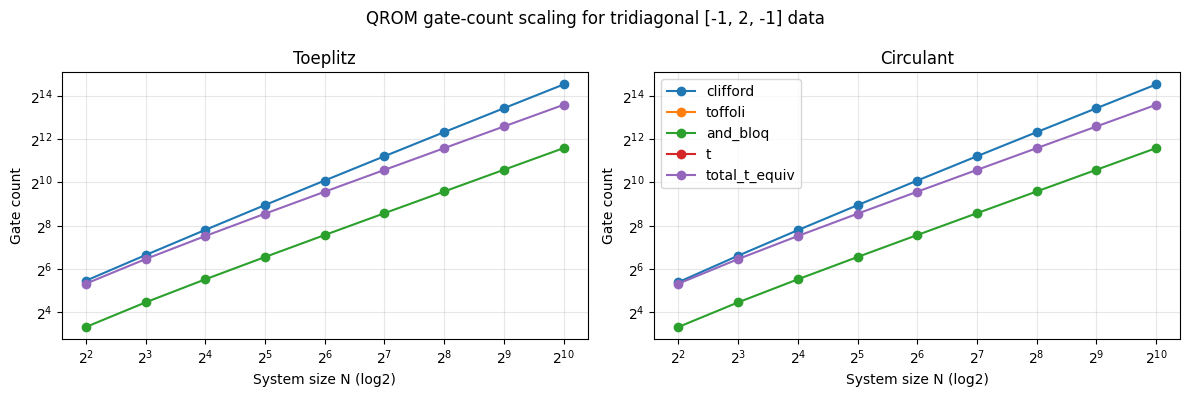

In [10]:
n = np.array(sizes, dtype=int)

metrics = ['clifford', 'toffoli', 'and_bloq', 't', 'total_t_equiv']
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for m in metrics:
    axes[0].plot(n, [r[m] for r in toeplitz_rows], marker='o', label=m)
    axes[1].plot(n, [r[m] for r in circulant_rows], marker='o', label=m)

for ax, title in zip(axes, ['Toeplitz', 'Circulant']):
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)
    ax.set_xlabel('System size N (log2)')
    ax.set_ylabel('Gate count')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[1].legend(loc='best')
plt.suptitle('QROM gate-count scaling for tridiagonal [-1, 2, -1] data')
plt.tight_layout()
plt.show()


## Notes
- We count resources for the QROM that stores `(col, value)` lookup tables.
- Values are encoded as non-negative integers via `v_enc = v + 1`.
- Toeplitz (open boundary) includes zero-value placeholders at edges; circulant does not.